## The Monty Hall Problem: A Probabilistic Simulation

The Monty Hall problem is a famous probability puzzle based on the American television game show *Let's Make a Deal*. The premise is simple:
* You are given the choice of three doors. Behind one door is a car; behind the others, goats.
* You pick a door (e.g., Door 1).
* The host, who knows what is behind the doors, opens another door (e.g., Door 3), revealing a goat.
* The host then asks: "Do you want to switch your choice to the remaining door?"

**The counterintuitive truth:** You should always switch. Switching gives you a **66.67%** chance of winning, while staying keeps your odds at **33.33%**. 

Instead of relying solely on mathematical proofs (like Bayes' Theorem), we can prove this empirically using a **Monte Carlo simulation**. The Python code below simulates 10,000,000 games to track the win rates of both strategies and visualizes how the probability converges to the theoretical truth over time.


--- Results after 10,000,000 simulated games ---
Win Rate if you STAY:   33.34%
Win Rate if you SWITCH: 66.66%


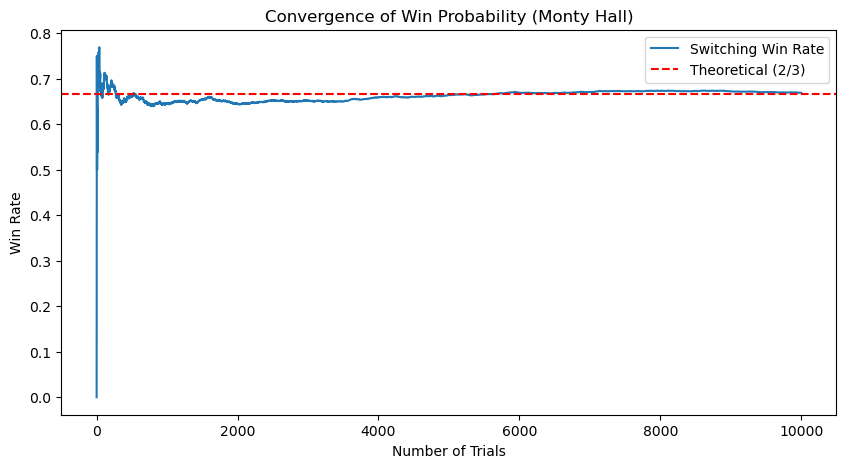

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def monty_hall(num_trials = 10_000_000):
    doors = np.random.randint(0,3,num_trials)
    choice = np.random.randint(0,3,num_trials)
    stay_wins = np.sum(doors == choice)
    swap_wins = np.sum(doors != choice)

    print(f"--- Results after {num_trials:,} simulated games ---")
    print(f"Win Rate if you STAY:   {stay_wins / num_trials * 100:.2f}%")
    print(f"Win Rate if you SWITCH: {swap_wins / num_trials * 100:.2f}%")

    sample_size = 10_000
    sample_wins = (doors[:sample_size] != choice[:sample_size])
    running_win_rate = np.cumsum(sample_wins) / np.arange(1, sample_size + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(running_win_rate, label="Switching Win Rate")
    plt.axhline(y=0.666, color='r', linestyle='--', label="Theoretical (2/3)")
    plt.title("Convergence of Win Probability (Monty Hall)")
    plt.xlabel("Number of Trials")
    plt.ylabel("Win Rate")
    plt.legend()
    plt.show()


monty_hall()

## The Law of Large Numbers: How Many Trials Are Enough?

In the first simulation, we saw the win rate converge perfectly to roughly **66.6%**. However, statistical simulations are subject to variance. If we only run the game 10 times, we might see a win rate of 80% or 40% purely due to random chance. 

This brings us to the **Law of Large Numbers (LLN)**, which dictates that as the size of a sample increases, its mean will get closer to the average of the whole population. 

To demonstrate this, the following code tests the simulation across exponentially increasing sample sizes ($n$). By plotting the observed win rate against the number of trials on a logarithmic scale, we can visualize the "wiggle" of variance at small sample sizes and watch it flatten out into a consistent, reliable probability.

n = 10       | Win Rate: 0.7000
n = 50       | Win Rate: 0.7800
n = 100      | Win Rate: 0.7200
n = 500      | Win Rate: 0.6680
n = 1000     | Win Rate: 0.6830
n = 5000     | Win Rate: 0.6572
n = 10000    | Win Rate: 0.6647
n = 50000    | Win Rate: 0.6715
n = 100000   | Win Rate: 0.6682
n = 500000   | Win Rate: 0.6676
n = 1000000  | Win Rate: 0.6666
n = 10000000 | Win Rate: 0.6665


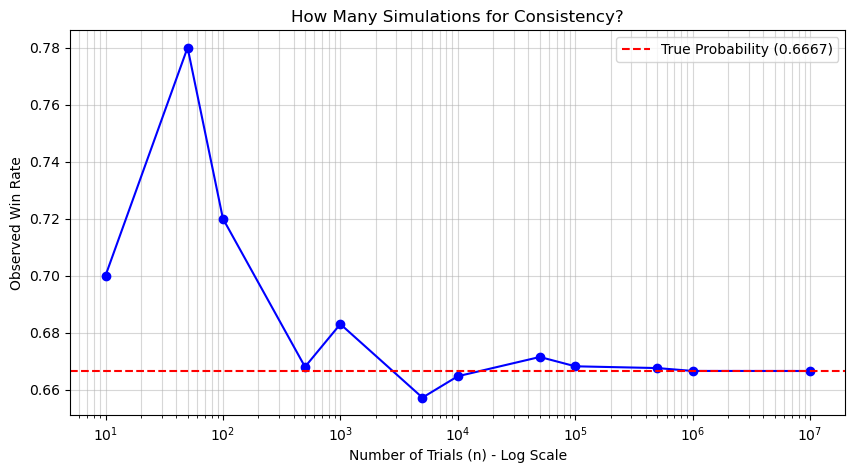

In [29]:
def test_consistency():
    n_values = [10, 50, 100, 500, 1000, 5000, 10_000, 50_000, 100_000, 500_000, 1_000_000, 10_000_000]
    results = []

    for n in n_values:
        # Run a fresh simulation for each n
        doors = np.random.randint(0, 3, n)
        choice = np.random.randint(0, 3, n)
        win_rate = np.sum(doors != choice) / n
        results.append(win_rate)
        print(f"n = {n:<8} | Win Rate: {win_rate:.4f}")

    # Plotting the 'Wiggle'
    plt.figure(figsize=(10, 5))
    plt.plot(n_values, results, marker='o', linestyle='-', color='b')
    plt.axhline(y=2/3, color='r', linestyle='--', label="True Probability (0.6667)")
    
    # Using a log scale for X makes it easier to see the convergence
    plt.xscale('log') 
    plt.title("How Many Simulations for Consistency?")
    plt.xlabel("Number of Trials (n) - Log Scale")
    plt.ylabel("Observed Win Rate")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

test_consistency()

## The Central Limit Theorem (CLT): The Average of Averages

To complete our statistical foundation, we will apply the **Central Limit Theorem (CLT)**. The CLT states that if you take sufficiently large random samples from a population with replacement, the distribution of the sample means will be approximately normally distributed (a bell curve), regardless of the original population's distribution.

Instead of running one massive simulation, we will now run **1,000 independent simulations**, each consisting of 100,000 trials. We will record the final win rate of each simulation and plot their distribution. 

**What to look for in the output:**
* **The Normal Distribution:** The histogram of our 1,000 win rates should form a bell curve centered around the theoretical mean of **0.6667**.
* **Confidence Intervals:** We will calculate the 95% confidence interval to show the range in which we can confidently expect the true mean to fall. This highlights the reliability and precision of our simulated data.

Running 1000 simulations...
--- CLT Results ---
Grand Average Win Rate: 66.6676%
Theoretical Truth:      66.6667%
95% Confidence Interval: [0.6637 to 0.6695]


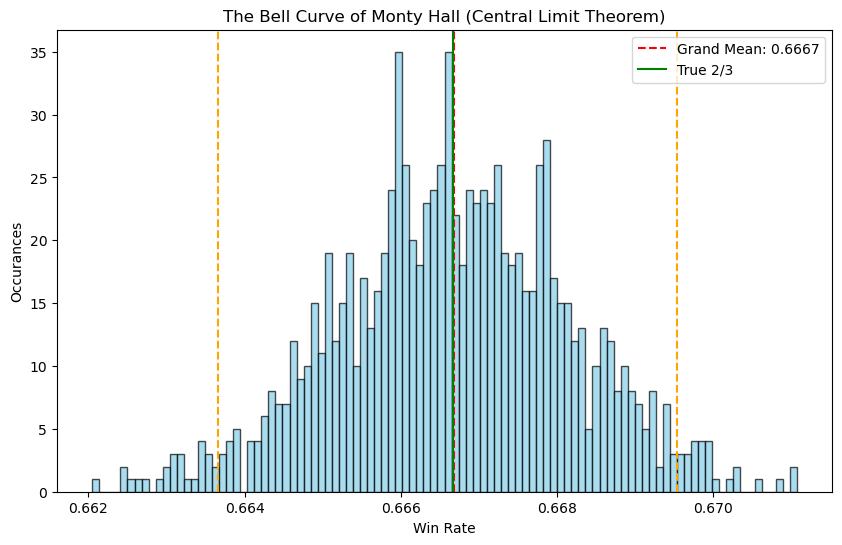

In [58]:
def monty_hall(num_trials=1000):
    doors = np.random.randint(0, 3, num_trials)
    choice = np.random.randint(0, 3, num_trials)
    swap_win_rate = np.sum(doors != choice) / num_trials
    return swap_win_rate

def run_clt_simulation(num_simulations=1000, trials_per_sim=100000):
    #store every result
    all_results = []
    
    print(f"Running {num_simulations} simulations...")
    
    for _ in range(num_simulations):
        #calling the monty function for every sim
        res = monty_hall(trials_per_sim)
        all_results.append(res)
    
    # Calculate the average
    grand_avg = np.mean(all_results)
    
    print(f"--- CLT Results ---")
    print(f"Grand Average Win Rate: {grand_avg * 100:.4f}%")
    print(f"Theoretical Truth:      66.6667%")
    
    # plot the curve
    plt.figure(figsize=(10, 6))
    plt.hist(all_results, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(grand_avg, color='red', linestyle='dashed', label=f'Grand Mean: {grand_avg:.4f}')
    plt.axvline(2/3, color='green', label='True 2/3')
    
    plt.title("The Bell Curve of Monty Hall (Central Limit Theorem)")
    plt.xlabel("Win Rate")
    plt.ylabel("Occurances")
    plt.legend()

    # Adding 95% confidence interval to plot and print
    ci_lower = np.percentile(all_results, 2.5)
    ci_upper = np.percentile(all_results, 97.5)
    print(f"95% Confidence Interval: [{ci_lower:.4f} to {ci_upper:.4f}]")
    plt.axvline(ci_lower, color='orange', linestyle='--', label='95% CI Lower')
    plt.axvline(ci_upper, color='orange', linestyle='--', label='95% CI Upper')
    plt.show()

run_clt_simulation()